In [1]:
# =====================================================================
# W4 — CELL SETUP (chạy ĐẦU TIÊN mỗi phiên). Baseline: Qwen2.5-VL-3B
# Việc: mount Drive · cài đúng version · log GPU · cố định seed · ghi env.json
# =====================================================================

# --- 1. Mount Google Drive (lưu data/adapter/log, sống qua các phiên) ---
from google.colab import drive
drive.mount('/content/drive')

# --- 2. Cài dependencies ----------------------------------------------
# Qwen2.5-VL cần transformers >= 4.49.0 (Colab thường đã có sẵn bản mới hơn).
# qwen-vl-utils: tiện ích xử lý ảnh đầu vào cho Qwen-VL.
# bitsandbytes: để nạp 4-bit/QLoRA — cài sẵn cho tuần train, W4 chưa dùng tới.
!pip install -q -U "transformers>=4.49.0" "qwen-vl-utils" accelerate bitsandbytes packaging "pillow<12"

# --- 3. Kiểm tra version + KHẲNG ĐỊNH đủ điều kiện ---------------------
import transformers, torch, importlib.metadata as meta
from packaging import version
def _v(pkg):
    try: return meta.version(pkg)
    except Exception: return "NOT INSTALLED"
assert version.parse(transformers.__version__) >= version.parse("4.49.0"), \
    f"transformers {transformers.__version__} < 4.49.0 → Restart runtime rồi chạy lại"

# --- 4. Log GPU (BẮT BUỘC mỗi run — Colab đổi GPU thất thường) --------
import subprocess
gpu = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,driver_version",
     "--format=csv,noheader"], capture_output=True, text=True).stdout.strip()
print("GPU:", gpu or "KHÔNG THẤY GPU → Runtime > Change runtime type > T4 GPU")
if torch.cuda.is_available():
    print("torch thấy:", torch.cuda.get_device_name(0), "| CUDA:", torch.version.cuda)

# --- 5. Cố định seed = 42 (chạy lại ra kết quả y hệt) -----------------
import random, numpy as np
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# --- 6. Đường dẫn dự án + model --------------------------------------
import os
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/ViVQA-VLM"          # ⚠️ SỬA cho khớp Drive của bạn
import sys
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
EXP_DIR = os.path.join(PROJECT_DIR, "experiments", "W04_zeroshot_qwen25vl_seed42")
os.makedirs(EXP_DIR, exist_ok=True)
MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"                  # baseline đã chốt
# reference-only (chạy sau nếu còn thời gian): "Qwen/Qwen3-VL-4B-Instruct"

# --- 7. In + lưu BẢNG VERSION để dán vào experiment log ---------------
import json
env = {
    "model_id": MODEL_ID, "seed": SEED, "gpu": gpu,
    "transformers": _v("transformers"), "torch": torch.__version__,
    "cuda": torch.version.cuda, "qwen-vl-utils": _v("qwen-vl-utils"),
    "bitsandbytes": _v("bitsandbytes"), "accelerate": _v("accelerate"),
    "pillow": _v("pillow"),
}
print(json.dumps(env, indent=2, ensure_ascii=False))
with open(os.path.join(EXP_DIR, "env.json"), "w", encoding="utf-8") as f:
    json.dump(env, f, indent=2, ensure_ascii=False)
print("\n✅ Setup xong. env.json đã lưu:", EXP_DIR)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 20.9 MB/s eta 0:00:00
GPU: Tesla T4, 15360 MiB, 0 MiB, 580.82.07
torch thấy: Tesla T4 | CUDA: 12.8
{
  "model_id": "Qwen/Qwen2.5-VL-3B-Instruct",
  "seed": 42,
  "gpu": "Tesla T4, 15360 MiB, 0 MiB, 580.82.07",
  "transformers": "5.17.0",
  "torch": "2.11.0+cu128",
  "cuda": "12.8",
  "qwen-vl-utils": "0.0.14",
  "bitsandbytes": "0.50.2",
  "accelerate": "1.15.0",
  "pillow": "11.3.0"
}

✅ Setup xong. env.json đã lưu: /content/drive/MyDrive/Colab Notebooks/ViVQA-VLM/experiments/W04_zeroshot_qwen25vl_seed42


In [2]:
# =====================================================================
# CELL 2 — Load Qwen2.5-VL-3B + zero-shot 1 ảnh. Chạy SAU cell setup.
# =====================================================================
import time, json, os, torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

# --- Ảnh để thử ---
# Mặc định: ảnh demo tải từ internet → chạy được ngay, không cần upload.
IMAGE = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"
# Ảnh tiếng Việt của bạn trên Drive (bỏ # và sửa tên file để thử scene-text thật):
# IMAGE = os.path.join(PROJECT_DIR, "data", "samples", "bien_hieu.jpg")

QUESTION = "Trong ảnh có gì? Trả lời ngắn gọn bằng tiếng Việt."

# --- 1. Load processor + model (T4 → float16) ---
print("Đang load model... (lần ĐẦU tải ~7GB, chờ vài phút; lần sau nhanh hơn)")
t0 = time.time()
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,          # 5.x dùng 'dtype'; T4 → float16 (KHÔNG bfloat16)
    device_map="auto",
    attn_implementation="sdpa",   # KHÔNG flash_attention_2 trên Colab (chưa cài sẵn)
)
model.eval()
print(f"Load xong {time.time()-t0:.1f}s | dtype thật:", next(model.parameters()).dtype)

# --- 2. Dựng input theo chuẩn chat của Qwen-VL ---
messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": IMAGE},
        {"type": "text",  "text": QUESTION},
    ],
}]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                   padding=True, return_tensors="pt").to(model.device)

# --- 3. Sinh câu trả lời (greedy = tái lập được) + đo VRAM & thời gian ---
torch.cuda.reset_peak_memory_stats()
t1 = time.time()
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=128, do_sample=False)
infer_s = time.time() - t1
gen = out[:, inputs.input_ids.shape[1]:]        # bỏ phần prompt, chỉ lấy câu trả lời
answer = processor.batch_decode(gen, skip_special_tokens=True)[0].strip()
vram_gb = torch.cuda.max_memory_allocated() / 1e9

# --- 4. In kết quả ---
print("\n" + "="*60)
print("CÂU HỎI :", QUESTION)
print("TRẢ LỜI :", answer)
print(f"⏱️ Inference: {infer_s:.1f}s | 🎮 VRAM đỉnh: {vram_gb:.1f}/15 GB")
print("="*60)

# --- 5. Lưu log (nguyên tắc: mọi thí nghiệm phải log) ---
log = {"model_id": MODEL_ID, "seed": SEED, "image": IMAGE, "question": QUESTION,
       "answer": answer, "infer_seconds": round(infer_s, 2), "vram_gb": round(vram_gb, 2)}
with open(os.path.join(EXP_DIR, "zeroshot_sample.json"), "w", encoding="utf-8") as f:
    json.dump(log, f, indent=2, ensure_ascii=False)
print("Đã lưu:", os.path.join(EXP_DIR, "zeroshot_sample.json"))

Đang load model... (lần ĐẦU tải ~7GB, chờ vài phút; lần sau nhanh hơn)


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Load xong 157.8s | dtype thật: torch.float16

CÂU HỎI : Trong ảnh có gì? Trả lời ngắn gọn bằng tiếng Việt.
TRẢ LỜI : Trong ảnh có một chiếc xe cổ màu xanh lá cây đậu trước một bức tường màu vàng. Xe có thiết kế kiểu dáng cổ điển, đặc trưng của dòng xe Volkswagen Beetle. Xe đậu trên một con đường gạch.
⏱️ Inference: 6.3s | 🎮 VRAM đỉnh: 7.6/15 GB
Đã lưu: /content/drive/MyDrive/Colab Notebooks/ViVQA-VLM/experiments/W04_zeroshot_qwen25vl_seed42/zeroshot_sample.json


Chọn 1 ảnh có chữ tiếng Việt để upload:


Saving 1.jpg to 1.jpg


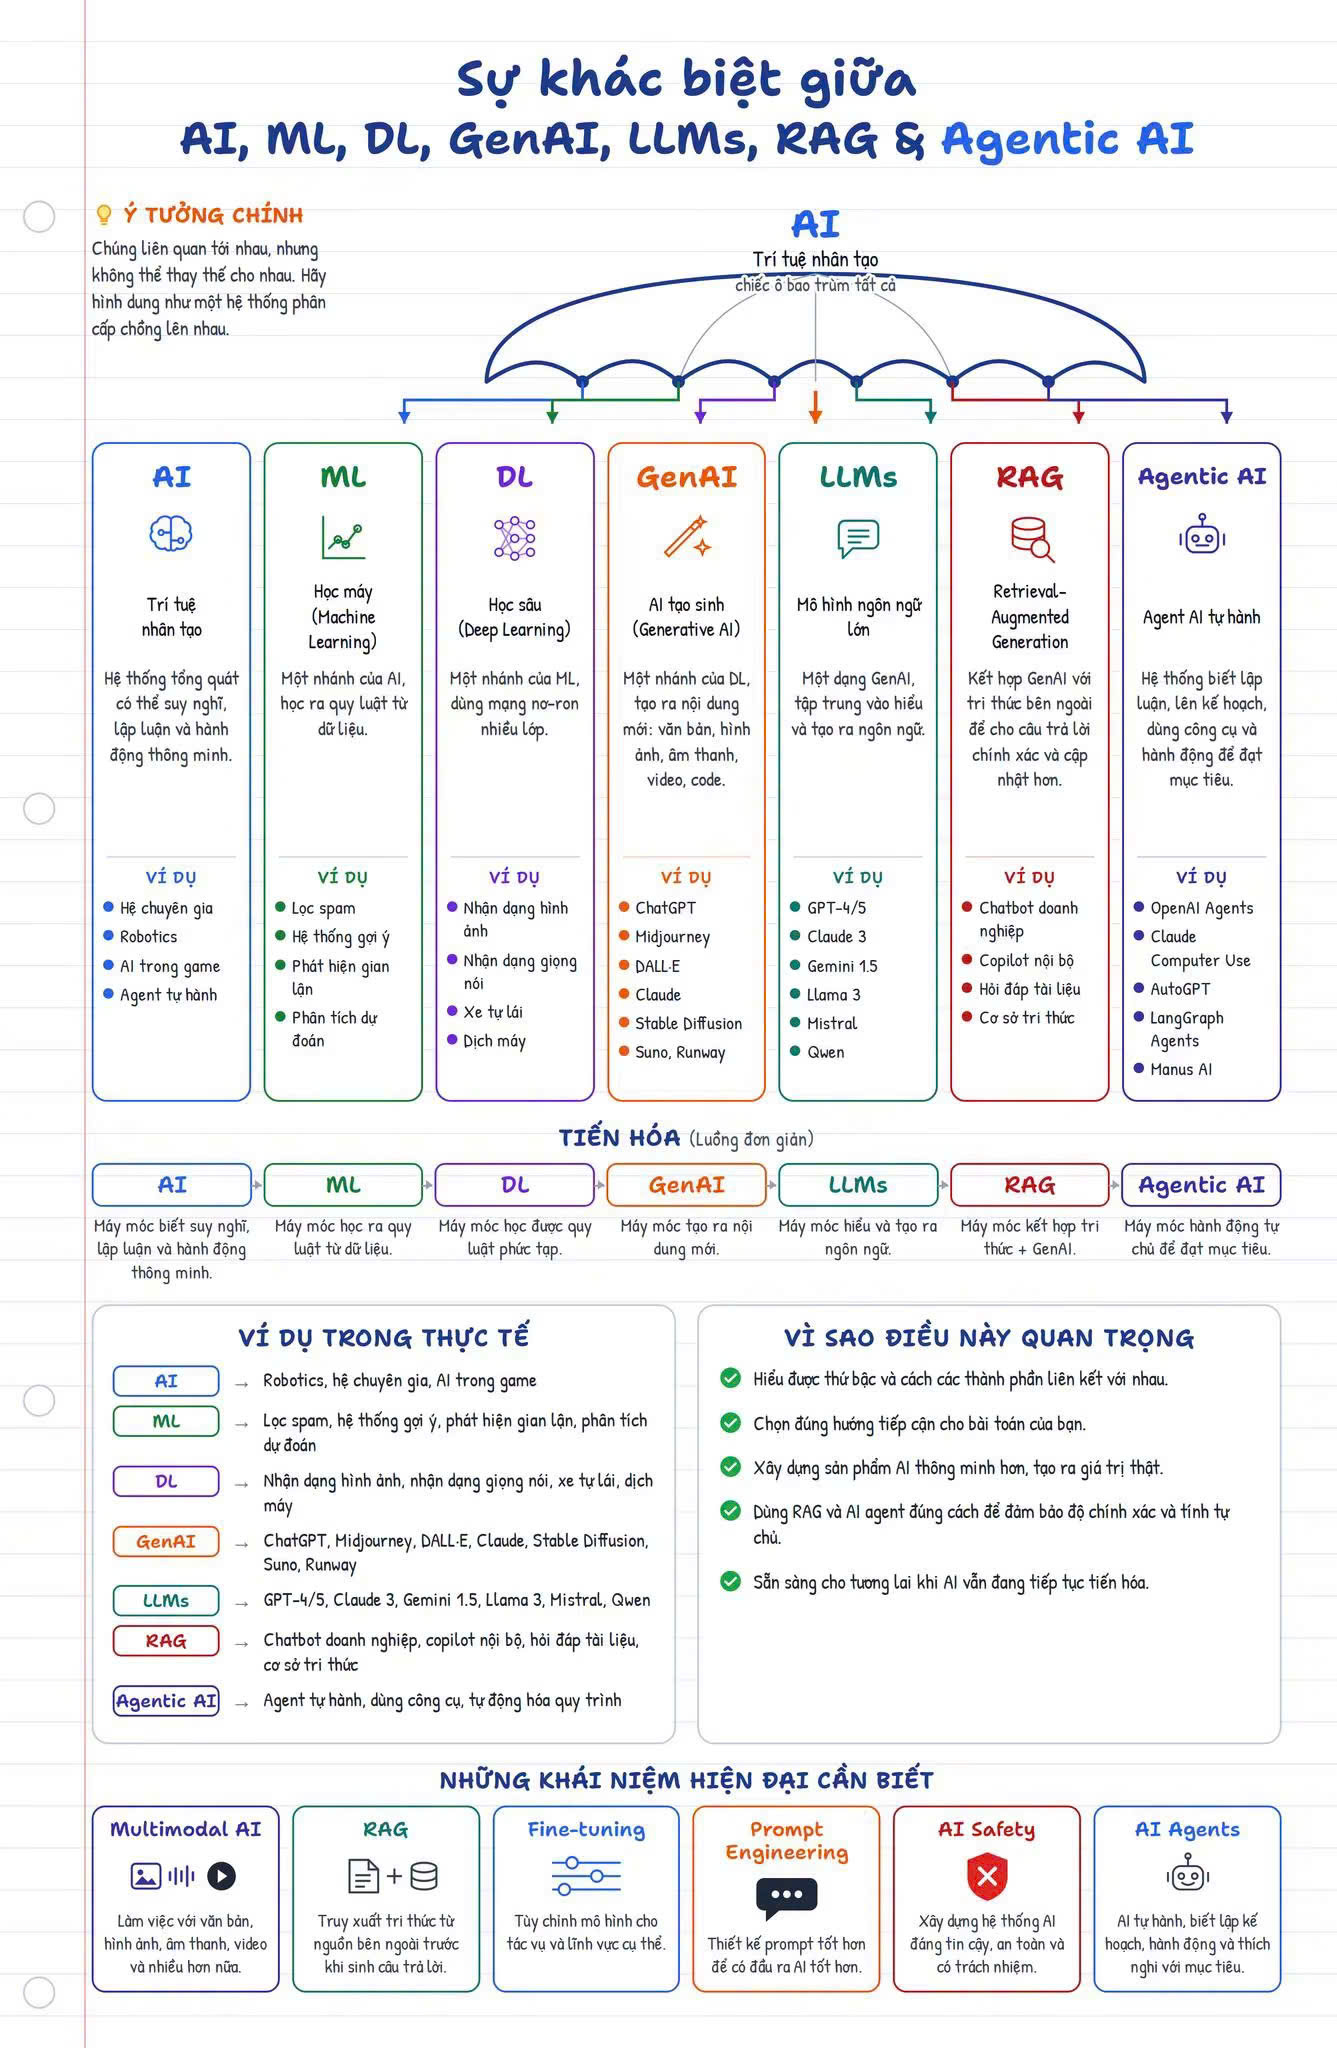


MODEL ĐỌC ĐƯỢC:
 Sự khác biệt giữa AI, ML, DL, GenAI, LLMs, RAG & Agentic AI

**Ý TƯỞNG CHÍNH**

Chúng liên quan tới nhau, nhưng không thể thay thế cho nhau. Hãy hình dung như một hệ thống phân cấp chồng lên nhau.

**AI**
- Trí tuệ nhân tạo
- Hệ thống tổng quát có thể suy nghĩ, lập luận và hành động thông minh.
- Ví dụ: Hệ chuyên gia, Robotics, AI trong game, Agent tự hành

**ML**
- Học máy (Machine Learning)
- Một nhánh của AI, học ra quy luật từ dữ liệu.
- Ví dụ: Lọc spam, Hệ thống gợi ý, Phát hiện gian lận, Phân tích dự đoán

**DL**
- Học sâu (Deep Learning)
- Một nhánh của ML, dùng mạng nơ-ron nhiều lớp.
- Ví dụ: Nhận dạng hình ảnh, Nhận dạng giọng nói, Xe tự lái, Dịch máy

**GenAI**
- AI tạo sinh (Generative AI)
- Một dạng GenAI, tập trung vào hiểu và tạo ra ngôn ngữ.
- Ví dụ: ChatGPT, Midjourney, DALL-E, Stable Diffusion, Suno, Runway

**LLMs**
- Mô hình ngôn ngữ lớn
- Ví dụ: GPT-4/5, Claude 3, Gemini 1.5, Llama 3, Mistral, Qwen

**RAG**
- Retrieval-Augmented Generation
- Ví dụ:

In [3]:
# =====================================================================
# CELL 3 — Zero-shot SCENE-TEXT tiếng Việt (đọc chữ trong ảnh).
# Dùng LẠI model + processor đã load ở cell 2 (KHÔNG load lại).
# =====================================================================
import time, torch
from PIL import Image
from IPython.display import display
from qwen_vl_utils import process_vision_info

# --- Upload 1 ảnh CÓ CHỮ TIẾNG VIỆT từ máy bạn (biển hiệu, menu, nhãn...) ---
from google.colab import files
print("Chọn 1 ảnh có chữ tiếng Việt để upload:")
uploaded = files.upload()
IMG_PATH = list(uploaded.keys())[0]
# (Hoặc ảnh sẵn trên Drive: IMG_PATH = os.path.join(PROJECT_DIR,"data","samples","bien_hieu.jpg"))

img = Image.open(IMG_PATH).convert("RGB")
display(img)   # xem lại ảnh ngay trong notebook để đối chiếu

QUESTION = ("Đọc chính xác toàn bộ chữ tiếng Việt xuất hiện trong ảnh, "
            "giữ nguyên dấu thanh. Nếu không có chữ, trả lời 'không có chữ'.")

messages = [{"role": "user", "content": [
    {"type": "image", "image": img},
    {"type": "text",  "text": QUESTION},
]}]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                   padding=True, return_tensors="pt").to(model.device)

torch.cuda.reset_peak_memory_stats()
t1 = time.time()
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=524, do_sample=False)
infer_s = time.time() - t1
gen = out[:, inputs.input_ids.shape[1]:]
answer = processor.batch_decode(gen, skip_special_tokens=True)[0].strip()

print("\n" + "="*60)
print("MODEL ĐỌC ĐƯỢC:\n", answer)
print(f"\n⏱️ {infer_s:.1f}s | 🎮 VRAM đỉnh: {torch.cuda.max_memory_allocated()/1e9:.1f}/15 GB")
print("="*60)
print("\n👉 Đối chiếu với chữ THẬT trong ảnh: đúng hết? THIẾU DẤU? sai chữ? BỊA thêm chữ không có?")

In [4]:
# =====================================================================
# CELL 3 — Zero-shot SCENE-TEXT tiếng Việt (đọc chữ trong ảnh).
# Dùng LẠI model + processor đã load ở cell 2 (KHÔNG load lại).
# =====================================================================
import time, torch
from PIL import Image
from IPython.display import display
from qwen_vl_utils import process_vision_info

# --- Upload 1 ảnh CÓ CHỮ TIẾNG VIỆT từ máy bạn (biển hiệu, menu, nhãn...) ---
from google.colab import files
print("Chọn 1 ảnh có chữ tiếng Việt để upload:")
uploaded = files.upload()
IMG_PATH = list(uploaded.keys())[0]
# (Hoặc ảnh sẵn trên Drive: IMG_PATH = os.path.join(PROJECT_DIR,"data","samples","bien_hieu.jpg"))

img = Image.open(IMG_PATH).convert("RGB")
display(img)   # xem lại ảnh ngay trong notebook để đối chiếu

QUESTION = ("Đọc chính xác toàn bộ chữ tiếng Việt xuất hiện trong ảnh, "
            "giữ nguyên dấu thanh. Nếu không có chữ, trả lời 'không có chữ'.")

messages = [{"role": "user", "content": [
    {"type": "image", "image": img},
    {"type": "text",  "text": QUESTION},
]}]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                   padding=True, return_tensors="pt").to(model.device)

torch.cuda.reset_peak_memory_stats()
t1 = time.time()
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=128, do_sample=False
                     )
infer_s = time.time() - t1
gen = out[:, inputs.input_ids.shape[1]:]
answer = processor.batch_decode(gen, skip_special_tokens=True)[0].strip()

print("\n" + "="*60)
print("MODEL ĐỌC ĐƯỢC:\n", answer)
print(f"\n⏱️ {infer_s:.1f}s | 🎮 VRAM đỉnh: {torch.cuda.max_memory_allocated()/1e9:.1f}/15 GB")
print("="*60)
print("\n👉 Đối chiếu với chữ THẬT trong ảnh: đúng hết? THIẾU DẤU? sai chữ? BỊA thêm chữ không có?")

Output hidden; open in https://colab.research.google.com to view.

In [5]:
# =====================================================================
# CELL B1 — Tải & SOI ViTextVQA từ HuggingFace. Chỉ để xem cấu trúc.
# =====================================================================
from huggingface_hub import list_repo_files, hf_hub_download
import json

REPO = "nhonhoccode/ViTextVQA"     # mirror MỞ (tiện bắt đầu W4)
# Bản CHÍNH THỨC (cần login HF + đồng ý điều khoản): "minhquan6203/ViTextVQA"

# 1) Liệt kê file trong dataset repo
files = list_repo_files(REPO, repo_type="dataset")
print(f"'{REPO}' có {len(files)} file:")
for f in files[:60]:
    print("   ", f)

# 2) Tải 1 file annotation JSON để soi field
json_files = [f for f in files if f.endswith(".json")]
cand = [f for f in json_files if any(k in f.lower()
        for k in ("train","val","test","annotation","data"))] or json_files
print("\nCác file .json:", json_files)

if cand:
    target = cand[0]
    local = hf_hub_download(REPO, target, repo_type="dataset")
    print("\nĐã tải:", target)
    with open(local, encoding="utf-8") as fp:
        data = json.load(fp)
    recs = (data.get("data") or list(data.values())) if isinstance(data, dict) else data
    print("Số record:", len(recs))
    print("\n--- 1 RECORD MẪU (field của nó chính là thứ mình cần) ---")
    print(json.dumps(recs[0], ensure_ascii=False, indent=2)[:900])

'nhonhoccode/ViTextVQA' có 9 file:
    .gitattributes
    README.md
    dev.json
    docr_features_of_vitext.npy
    images.zip
    output_em0.json
    test.json
    train.json
    vitextvqa_captions.json

Các file .json: ['dev.json', 'output_em0.json', 'test.json', 'train.json', 'vitextvqa_captions.json']


test.json:   0%|          | 0.00/2.68M [00:00<?, ?B/s]


Đã tải: test.json
Số record: 2

--- 1 RECORD MẪU (field của nó chính là thứ mình cần) ---
[
  {
    "id": 2145,
    "filename": "2145.jpg"
  },
  {
    "id": 4358,
    "filename": "4358.jpg"
  },
  {
    "id": 2408,
    "filename": "2408.jpg"
  },
  {
    "id": 4791,
    "filename": "4791.jpg"
  },
  {
    "id": 5566,
    "filename": "5566.jpg"
  },
  {
    "id": 7616,
    "filename": "7616.jpg"
  },
  {
    "id": 7688,
    "filename": "7688.jpg"
  },
  {
    "id": 12918,
    "filename": "12918.jpg"
  },
  {
    "id": 1730,
    "filename": "1730.jpg"
  },
  {
    "id": 7786,
    "filename": "7786.jpg"
  },
  {
    "id": 15984,
    "filename": "15984.jpg"
  },
  {
    "id": 2665,
    "filename": "2665.jpg"
  },
  {
    "id": 12674,
    "filename": "12674.jpg"
  },
  {
    "id": 5053,
    "filename": "5053.jpg"
  },
  {
    "id": 6489,
    "filename": "6489.jpg"
  },
  {
    "id": 3949,
    "filename": "3949.jpg"
  },
  {
    "id": 5131,
    "filename": "5131.jpg"
  },
  {
    


In [6]:
import json
from huggingface_hub import hf_hub_download

REPO = "nhonhoccode/ViTextVQA"
local = hf_hub_download(REPO, "test.json", repo_type="dataset")  # đã cache, không tải lại
with open(local, encoding="utf-8") as fp:
    data = json.load(fp)

print("Kiểu tầng trên cùng:", type(data).__name__)
print("Các key:", list(data.keys()))
for k, v in data.items():
    n = len(v) if isinstance(v, (list, dict)) else "-"
    print(f"\n▶ key '{k}': kiểu {type(v).__name__}, số phần tử {n}")
    if isinstance(v, list) and v:
        print("   phần tử[0]:", json.dumps(v[0], ensure_ascii=False)[:500])
    elif isinstance(v, dict):
        kk = list(v.keys())[:5]
        print("   vài key con:", kk)
        if kk:
            print("   ví dụ 1 value:", json.dumps(v[kk[0]], ensure_ascii=False)[:500])

Kiểu tầng trên cùng: dict
Các key: ['images', 'annotations']

▶ key 'images': kiểu list, số phần tử 3353
   phần tử[0]: {"id": 2145, "filename": "2145.jpg"}

▶ key 'annotations': kiểu list, số phần tử 10028
   phần tử[0]: {"id": 29, "image_id": 9, "question": "tiệm thuốc này bán kẹo gì ?", "answers": ["cool air"]}


In [7]:
# =====================================================================
# CELL B2 — Tải images.zip + test.json về DRIVE, giải nén, build list phẳng.
# Chạy trên Colab. Có kiểm tra "đã có thì bỏ qua" để không tải lại.
# =====================================================================
import os, json, zipfile
from huggingface_hub import hf_hub_download

REPO = "nhonhoccode/ViTextVQA"
DATA_DIR = os.path.join(PROJECT_DIR, "data", "vitextvqa")   # lưu BỀN trên Drive
IMG_DIR  = os.path.join(DATA_DIR, "images")
os.makedirs(DATA_DIR, exist_ok=True)

# 1) test.json → Drive (nhỏ)
test_json = os.path.join(DATA_DIR, "test.json")
if not os.path.exists(test_json):
    src = hf_hub_download(REPO, "test.json", repo_type="dataset")
    import shutil; shutil.copy(src, test_json)
print("✅ test.json:", test_json)

# 2) images.zip → Drive rồi giải nén (CHỈ làm nếu chưa giải nén)
if not os.path.isdir(IMG_DIR) or len(os.listdir(IMG_DIR)) == 0:
    print("Đang tải images.zip (nặng, lần đầu chờ vài phút)...")
    zip_local = hf_hub_download(REPO, "images.zip", repo_type="dataset",
                                cache_dir=os.path.join(DATA_DIR, "_hf_cache"))
    print("Giải nén vào Drive...")
    with zipfile.ZipFile(zip_local) as z:
        z.extractall(IMG_DIR)
else:
    print("✅ Ảnh đã có sẵn, bỏ qua tải.")

# 3+4) Tìm thư mục ảnh + join COCO-style → list phẳng (src/data/prepare_vitextvqa.py)
from src.data.prepare_vitextvqa import find_image_root, flatten_coco_file

IMG_ROOT = find_image_root(IMG_DIR)
print("Ảnh nằm ở:", IMG_ROOT, "| số ảnh:",
      sum(1 for f in os.listdir(IMG_ROOT) if f.lower().endswith(".jpg")))

flat_path = os.path.join(DATA_DIR, "test_flat.json")
flat = flatten_coco_file(test_json, out_path=flat_path)
print(f"\n✅ Đã build {len(flat)} record phẳng → {flat_path}")
print("Ví dụ:", json.dumps(flat[0], ensure_ascii=False))

✅ test.json: /content/drive/MyDrive/Colab Notebooks/ViVQA-VLM/data/vitextvqa/test.json
Đang tải images.zip (nặng, lần đầu chờ vài phút)...


images.zip: reconstructing file:   0%|          |  0.00B / 5.59GB            

images.zip: downloading bytes:           |  0.00B            

Giải nén vào Drive...
Ảnh nằm ở: /content/drive/MyDrive/Colab Notebooks/ViVQA-VLM/data/vitextvqa/images/images | số ảnh: 16762

✅ Đã build 10028 record phẳng → /content/drive/MyDrive/Colab Notebooks/ViVQA-VLM/data/vitextvqa/test_flat.json
Ví dụ: {"question_id": 29, "question": "tiệm thuốc này bán kẹo gì ?", "answers": ["cool air"], "image": "9.jpg", "question_type": "unknown"}


In [8]:
# =====================================================================
# CELL B3 — Zero-shot ViTextVQA (data thật) + in kèm đáp án chuẩn.
# Dùng lại model/processor từ cell 2. Chưa ghép metric — chỉ xem định tính.
# =====================================================================
import os, json, time, torch
from PIL import Image
from qwen_vl_utils import process_vision_info

DATA_DIR = os.path.join(PROJECT_DIR, "data", "vitextvqa")
with open(os.path.join(DATA_DIR, "test_flat.json"), encoding="utf-8") as fp:
    samples = json.load(fp)

# max_pixels: giảm visual token để KHÔNG OOM trên ảnh chụp thật (như ảnh sách 14.2GB)
from transformers import AutoProcessor
processor = AutoProcessor.from_pretrained(MODEL_ID, max_pixels=1024*28*28)

N = 20
PROMPT = ("Trả lời câu hỏi bằng tiếng Việt, NGẮN GỌN, chỉ nêu đáp án "
          "dựa trên chữ và nội dung trong ảnh. Câu hỏi: {q}")

results = []
for i, s in enumerate(samples[:N]):
    img_path = os.path.join(IMG_ROOT, s["image"])
    if not os.path.exists(img_path):
        print(f"[{i}] THIẾU ẢNH: {s['image']}"); continue
    img = Image.open(img_path).convert("RGB")
    messages = [{"role":"user","content":[
        {"type":"image","image":img},
        {"type":"text","text":PROMPT.format(q=s["question"])},
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, padding=True,
                       return_tensors="pt").to(model.device)
    t1 = time.time()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=32, do_sample=False)
    pred = processor.batch_decode(out[:, inputs.input_ids.shape[1]:],
                                  skip_special_tokens=True)[0].strip()
    dt = time.time() - t1
    results.append({"question_id": s["question_id"], "question": s["question"],
                    "gold": s["answers"], "pred": pred, "sec": round(dt,2)})
    print(f"\n[{i+1}/{N}] Q: {s['question']}")
    print(f"    ✅ Đáp án chuẩn: {s['answers']}")
    print(f"    🤖 Model:        {pred}   ({dt:.1f}s)")

# Lưu để bước metric dùng lại
out_path = os.path.join(EXP_DIR, "zeroshot_vitextvqa_n{}.json".format(N))
with open(out_path, "w", encoding="utf-8") as fp:
    json.dump(results, fp, ensure_ascii=False, indent=2)
print("\n✅ Đã lưu", len(results), "kết quả →", out_path)


[1/20] Q: tiệm thuốc này bán kẹo gì ?
    ✅ Đáp án chuẩn: ['cool air']
    🤖 Model:        Kẹo Cool Air   (3.4s)

[2/20] Q: tiệm thuốc này bán kẹo gì ?
    ✅ Đáp án chuẩn: ['doublemint']
    🤖 Model:        Kẹo Cool Air   (2.8s)

[3/20] Q: tiệm thuốc này bán kẹo gì ?
    ✅ Đáp án chuẩn: ['alpenliebe']
    🤖 Model:        Kẹo Cool Air   (3.0s)

[4/20] Q: tiệm thuốc này bán khẩu trang gì ?
    ✅ Đáp án chuẩn: ['medmask']
    🤖 Model:        MEDMask   (1.2s)

[5/20] Q: nơi này là đâu ?
    ✅ Đáp án chuẩn: ['bảo tàng lịch sử quốc gia']
    🤖 Model:        Đại sảnh Quốc hội Việt Nam   (0.7s)

[6/20] Q: đây là bảo tàng gì ?
    ✅ Đáp án chuẩn: ['lịch sử quốc gia']
    🤖 Model:        Bảo tàng Lịch sử Quốc gia.   (0.9s)

[7/20] Q: đây là đâu ?
    ✅ Đáp án chuẩn: ['bảo tàng']
    🤖 Model:        Đây là Bảo tàng Lịch sử Quốc gia Hà Nội.   (1.1s)

[8/20] Q: quầy hàng dầu ăn trong ảnh đang số sự kiện gì ?
    ✅ Đáp án chuẩn: ['khuyến mãi']
    🤖 Model:        Khuyến mãi   (1.2s)

[9/20] Q: phía

In [9]:
# =====================================================================
# CELL B4 — Metric: EM & ANLS (+ ghi chú VQA-Acc). Chấm kết quả zero-shot.
# =====================================================================
import json, os
from src.eval.metrics import normalize_vi, exact_match, anls, evaluate_predictions

with open(os.path.join(EXP_DIR, "zeroshot_vitextvqa_n20.json"), encoding="utf-8") as f:
    R = json.load(f)

# Per-row: exact_match / anls (normalize_vi nằm trong hai hàm đó).
# Aggregate: evaluate_predictions — cùng nguồn src.eval.metrics, không copy hàm.
rows = [(r["question_id"], exact_match(r["pred"], r["gold"]), anls(r["pred"], r["gold"]),
         r["pred"], r["gold"]) for r in R]
scores = evaluate_predictions(
    [r["pred"] for r in R],
    [r["gold"] for r in R],
    metric_names=["exact_match", "anls"],
)
EM = scores["exact_match"]
ANLS = scores["anls"]

print(f"{'ID':>6} {'EM':>4} {'ANLS':>5}  pred | gold")
for qid, e, a, pred, gold in rows:
    print(f"{qid:>6} {e:>4.0f} {a:>5.2f}  {pred[:28]!r} | {gold}")
print("\n" + "="*50)
print(f"BASELINE Qwen2.5-VL-3B zero-shot (n={len(R)}, ViTextVQA mirror)")
print(f"  Exact Match (EM):  {EM*100:.1f}%")
print(f"  ANLS:              {ANLS*100:.1f}%")
print(f"  VQA-Accuracy:      ≈ EM ({EM*100:.1f}%) — vì mỗi câu chỉ 1 đáp án chuẩn")
print("="*50)

    ID   EM  ANLS  pred | gold
    29    0  0.67  'Kẹo Cool Air' | ['cool air']
    30    0  0.00  'Kẹo Cool Air' | ['doublemint']
    31    0  0.00  'Kẹo Cool Air' | ['alpenliebe']
    32    1  1.00  'MEDMask' | ['medmask']
    33    0  0.00  'Đại sảnh Quốc hội Việt Nam' | ['bảo tàng lịch sử quốc gia']
    34    0  0.64  'Bảo tàng Lịch sử Quốc gia.' | ['lịch sử quốc gia']
    35    0  0.00  'Đây là Bảo tàng Lịch sử Quốc' | ['bảo tàng']
    36    1  1.00  'Khuyến mãi' | ['khuyến mãi']
    37    0  0.00  'Thực phẩm' | ['bánh biscuits']
    38    0  0.67  '32.000' | ['32500']
    39    0  0.67  '44.000' | ['44500']
    55    0  0.00  'Thúy Cánh Farm' | ['nông trại vui vẻ']
    56    0  0.88  'ĐC: 121C2 - KDC An Bình, BH ' | ['121c2 - kdc an bình , bh - đn']
    57    0  0.77  '0912 99 21 21' | ['0912992121']
    72    0  0.00  'Tấm bảng màu vàng được sử dụ' | ['vách ngăn covid - 19']
    73    0  0.79  'BÁN SẴN VÁCH NGĂN MICA TRONG' | ['vách ngăn mica trong ngừa covid 19s']
    78    0  

In [10]:
# =====================================================================
# CELL B5 — Baseline VỮNG: zero-shot n=300 NGẪU NHIÊN (seed 42), CÓ RESUME.
# Colab ngắt → chạy lại, tự bỏ qua mẫu đã làm.
# =====================================================================
import os, json, time, random, torch
from PIL import Image
from transformers import AutoProcessor
from qwen_vl_utils import process_vision_info

DATA_DIR = os.path.join(PROJECT_DIR, "data", "vitextvqa")
with open(os.path.join(DATA_DIR, "test_flat.json"), encoding="utf-8") as fp:
    all_samples = json.load(fp)

# Mẫu ĐẠI DIỆN: shuffle seed 42 rồi lấy N (đầu file bị gom theo ảnh → KHÔNG dùng [:N])
N = 300
pool = all_samples[:]
random.Random(42).shuffle(pool)
subset = pool[:N]

# processor có max_pixels để KHÔNG OOM trên ảnh chụp thật
processor = AutoProcessor.from_pretrained(MODEL_ID, max_pixels=1024*28*28)

PROG = os.path.join(EXP_DIR, f"zeroshot_vitextvqa_n{N}_seed42.json")
done = {}
if os.path.exists(PROG):
    with open(PROG, encoding="utf-8") as fp:
        done = {r["question_id"]: r for r in json.load(fp)}
    print(f"↻ Resume: đã có {len(done)}/{N}, chạy tiếp.")

PROMPT = ("Trả lời câu hỏi bằng tiếng Việt, NGẮN GỌN, chỉ nêu đáp án "
          "dựa trên chữ và nội dung trong ảnh. Câu hỏi: {q}")

results = list(done.values())
t0 = time.time()
for s in subset:
    if s["question_id"] in done:
        continue
    p = os.path.join(IMG_ROOT, s["image"])
    if not os.path.exists(p):
        continue
    img = Image.open(p).convert("RGB")
    msg = [{"role":"user","content":[
        {"type":"image","image":img},
        {"type":"text","text":PROMPT.format(q=s["question"])}]}]
    text = processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(msg)
    inputs = processor(text=[text], images=image_inputs, padding=True,
                       return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=32, do_sample=False)
    pred = processor.batch_decode(out[:, inputs.input_ids.shape[1]:],
                                  skip_special_tokens=True)[0].strip()
    results.append({"question_id": s["question_id"], "question": s["question"],
                    "gold": s["answers"], "pred": pred, "image": s["image"]})
    if len(results) % 10 == 0:                       # lưu tiến độ chống mất
        json.dump(results, open(PROG,"w",encoding="utf-8"), ensure_ascii=False)
        print(f"  {len(results)}/{N}  ({(time.time()-t0)/max(len(results)-len(done),1):.1f}s/mẫu)")

json.dump(results, open(PROG,"w",encoding="utf-8"), ensure_ascii=False)
print(f"\n✅ Xong {len(results)}/{N} → {PROG}")

  10/300  (1.9s/mẫu)
  20/300  (1.7s/mẫu)
  30/300  (1.6s/mẫu)
  40/300  (1.5s/mẫu)
  50/300  (1.5s/mẫu)
  60/300  (1.4s/mẫu)
  70/300  (1.4s/mẫu)
  80/300  (1.4s/mẫu)
  90/300  (1.4s/mẫu)
  100/300  (1.4s/mẫu)
  110/300  (1.3s/mẫu)
  120/300  (1.3s/mẫu)
  130/300  (1.3s/mẫu)
  140/300  (1.3s/mẫu)
  150/300  (1.3s/mẫu)
  160/300  (1.3s/mẫu)
  170/300  (1.3s/mẫu)
  180/300  (1.3s/mẫu)
  190/300  (1.3s/mẫu)
  200/300  (1.3s/mẫu)
  210/300  (1.3s/mẫu)
  220/300  (1.3s/mẫu)
  230/300  (1.3s/mẫu)
  240/300  (1.3s/mẫu)
  250/300  (1.3s/mẫu)
  260/300  (1.3s/mẫu)
  270/300  (1.3s/mẫu)
  280/300  (1.3s/mẫu)
  290/300  (1.3s/mẫu)
  300/300  (1.3s/mẫu)

✅ Xong 300/300 → /content/drive/MyDrive/Colab Notebooks/ViVQA-VLM/experiments/W04_zeroshot_qwen25vl_seed42/zeroshot_vitextvqa_n300_seed42.json


In [11]:
# =====================================================================
# CELL B6 — Chấm EM & ANLS trên 300 mẫu. (dùng lại logic B4)
# =====================================================================
import json, os
from src.eval.metrics import normalize_vi, exact_match, anls, evaluate_predictions

FILE = os.path.join(EXP_DIR, "zeroshot_vitextvqa_n300_seed42.json")
with open(FILE, encoding="utf-8") as f:
    R = json.load(f)

# Nguồn DUY NHẤT: src.eval.metrics (bản (b)). Không copy normalize/lev/em/anls.
scores = evaluate_predictions(
    [r["pred"] for r in R],
    [r["gold"] for r in R],
    metric_names=["exact_match", "anls"],
)
EM = scores["exact_match"]
ANLS = scores["anls"]

# thống kê thêm: bao nhiêu câu model trả lời DÀI hơn đáp án (nghi thừa chữ)
long_ans = sum(1 for r in R if len(r["pred"]) > len(max(r["gold"], key=len)) + 5)

print("="*56)
print(f"BASELINE Qwen2.5-VL-3B zero-shot")
print(f"  Dataset : ViTextVQA (mirror nhonhoccode), test split")
print(f"  n = {len(R)}, seed 42, max_pixels=1024*28*28, greedy")
print(f"  ─────────────────────────────────────────")
print(f"  Exact Match (EM):  {EM*100:5.1f}%")
print(f"  ANLS:              {ANLS*100:5.1f}%")
print(f"  EM↔ANLS gap:       {(ANLS-EM)*100:5.1f} điểm")
print(f"  Câu trả lời DÀI (nghi thừa chữ): {long_ans}/{len(R)} ({long_ans/len(R)*100:.0f}%)")
print("="*56)

BASELINE Qwen2.5-VL-3B zero-shot
  Dataset : ViTextVQA (mirror nhonhoccode), test split
  n = 300, seed 42, max_pixels=1024*28*28, greedy
  ─────────────────────────────────────────
  Exact Match (EM):   38.3%
  ANLS:               55.9%
  EM↔ANLS gap:        17.6 điểm
  Câu trả lời DÀI (nghi thừa chữ): 87/300 (29%)
